# EDA — commerces-par-commune-arrondissement.csv
Urban Data Explorer · Île-de-France — Base Permanente des Équipements

## 1. Chargement

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

In [2]:
# ⚠️ Change le chemin si besoin
FILE = '..\\brute\\les-commerces-par-commune-ou-arrondissement-base-permanente-des-equipements.csv'

df = pd.read_csv(FILE, sep=None, engine='python')
print(f'Shape : {df.shape}')
df.head()

Shape : (1300, 33)


,departement,departement_commune,libelle_de_commune,arrondissement,canton_ville,zone_d_emploi,unite_urbaine,population_2010,hypermarche,supermarche,...,magasin_d_articles_de_sports_et_de_loisirs,magasin_de_revetements_murs_et_sols,droguerie_quincaillerie_bricolage,parfumerie,horlogerie_bijouterie,fleuriste,magasin_d_optique,station_service,geo_point_2d,geo_shape
0,94,94074,Valenton,941,9447,1118,851,12081,0,3,...,0,0,0,2,0,1,0,2,"48.7528724020014,2.461294795734387","{""coordinates"": [[[2.472978586691335, 48.72757..."
1,95,95427,Montmagny,952,9509,56,851,14250,0,1,...,1,0,0,0,1,2,1,1,"48.96991958406158,2.346075317904123","{""coordinates"": [[[2.333312950123798, 48.95538..."
2,91,91619,Torfou,911,9109,1115,91000,272,0,0,...,0,0,0,0,0,0,0,0,"48.53204942675463,2.234472045873927","{""coordinates"": [[[2.235403341803649, 48.52167..."
3,95,95183,Courdimanche,953,9539,1119,851,6495,0,0,...,0,0,1,1,0,0,0,0,"49.040676792977436,1.9994435918049531","{""coordinates"": [[[1.9915275372253372, 49.0237..."
4,77,77197,Frétoy,773,7723,1103,77000,155,0,0,...,0,0,0,0,0,0,0,0,"48.706357723270294,3.202607504719354","{""coordinates"": [[[3.212320353639203, 48.69176..."


## 2. Infos générales

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 33 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   departement                                     1300 non-null   int64 
 1   departement_commune                             1300 non-null   int64 
 2   libelle_de_commune                              1300 non-null   object
 3   arrondissement                                  1300 non-null   int64 
 4   canton_ville                                    1300 non-null   int64 
 5   zone_d_emploi                                   1300 non-null   int64 
 6   unite_urbaine                                   1300 non-null   int64 
 7   population_2010                                 1300 non-null   int64 
 8   hypermarche                                     1300 non-null   int64 
 9   supermarche                                     1300

In [4]:
df.describe(include='all')

,departement,departement_commune,libelle_de_commune,arrondissement,canton_ville,zone_d_emploi,unite_urbaine,population_2010,hypermarche,supermarche,...,magasin_d_articles_de_sports_et_de_loisirs,magasin_de_revetements_murs_et_sols,droguerie_quincaillerie_bricolage,parfumerie,horlogerie_bijouterie,fleuriste,magasin_d_optique,station_service,geo_point_2d,geo_shape
count,1300.000000,1300.000000,1300,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,...,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300,1300
unique,NaN,NaN,1296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1300,1300
top,NaN,NaN,Marolles-en-Brie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"49.10722559241552,2.23436241794811","{""coordinates"": [[[2.250877875868919, 49.09078..."
freq,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
mean,83.365385,83645.627692,NaN,835.930769,8358.317692,986.340000,54159.081538,9066.333846,0.143846,1.247692,...,0.946154,0.296923,0.757692,1.516923,1.516923,2.183846,2.106154,0.691538,NaN,NaN
std,7.746337,7740.687821,NaN,77.385122,777.385541,338.702367,38645.685943,21316.429683,0.431711,3.502143,...,3.135168,1.495023,2.688423,7.142378,7.936557,6.700859,7.166735,1.336785,NaN,NaN
min,75.000000,75101.000000,NaN,751.000000,7599.000000,56.000000,260.000000,28.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,77.000000,77313.750000,NaN,773.000000,7722.000000,1103.000000,851.000000,544.500000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,78.000000,78310.500000,NaN,781.000000,7810.000000,1108.000000,77000.000000,1339.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,91.000000,91645.750000,NaN,913.000000,9135.000000,1115.000000,78000.000000,6775.500000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,NaN,NaN


## 3. Valeurs manquantes

In [5]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print('✅ Aucune valeur manquante')
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    ax.barh(missing.index, missing.values, color='#378ADD')
    ax.set_xlabel('% manquant')
    ax.set_title('Valeurs manquantes par colonne')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.show()
    display(missing.rename('% manquant').to_frame())

✅ Aucune valeur manquante


## 4. Doublons

In [6]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

Doublons : 0 (0.00%)


## 5. Détection des colonnes clés

In [7]:
ADMIN_COLS = ['departement', 'departement_commune', 'libelle_de_commune',
              'arrondissement', 'canton_ville', 'zone_d_emploi',
              'unite_urbaine', 'population_2010', 'geo_point_2d', 'geo_shape']
COMMERCE_COLS = [c for c in df.columns if c not in ADMIN_COLS]

DEPT_NAMES = {
    75: 'Paris', 77: 'Seine-et-Marne', 78: 'Yvelines',
    91: 'Essonne', 92: 'Hauts-de-Seine',
    93: 'Seine-Saint-Denis', 94: 'Val-de-Marne', 95: "Val-d'Oise"
}

# Extraction lat / lon
coords = df['geo_point_2d'].str.split(',', expand=True)
df['lat'] = pd.to_numeric(coords[0].str.strip(), errors='coerce')
df['lon'] = pd.to_numeric(coords[1].str.strip(), errors='coerce')

# Total commerces par commune
df['total_commerces'] = df[COMMERCE_COLS].sum(axis=1)
df['dept_label'] = df['departement'].map(DEPT_NAMES)

for label, val in [
    ('Colonnes commerces', len(COMMERCE_COLS)),
    ('Départements', df['departement'].nunique()),
    ('Communes', df['libelle_de_commune'].nunique()),
    ('Total commerces IDF', f"{df['total_commerces'].sum():,.0f}"),
    ('Communes sans commerce', (df['total_commerces'] == 0).sum()),
]:
    status = '✅'
    print(f'{status}  {label:30s} → {val}')

✅  Colonnes commerces             → 23
✅  Départements                   → 8
✅  Communes                       → 1296
✅  Total commerces IDF            → 59,419
✅  Communes sans commerce         → 355


## 6. Répartition par département

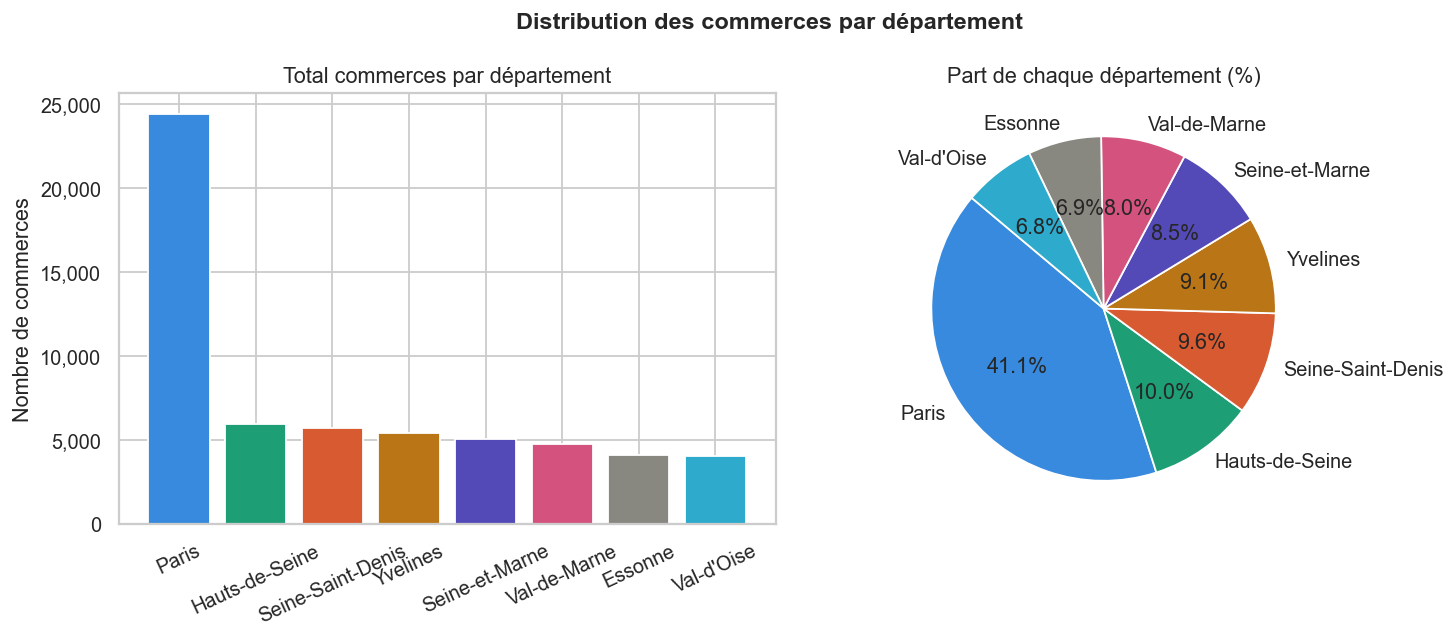

,Département,Total commerces
2,Paris,24404
1,Hauts-de-Seine,5915
3,Seine-Saint-Denis,5732
7,Yvelines,5429
4,Seine-et-Marne,5064
6,Val-de-Marne,4758
0,Essonne,4093
5,Val-d'Oise,4024


In [8]:
vc_dept = df.groupby('dept_label')['total_commerces'].sum().reset_index()
vc_dept.columns = ['dept', 'total']
vc_dept = vc_dept.sort_values('total', ascending=False)

colors = ['#378ADD','#1D9E75','#D85A30','#BA7517','#534AB7','#D4537E','#888780','#2EAACC']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(vc_dept['dept'], vc_dept['total'], color=colors[:len(vc_dept)])
ax1.set_title("Total commerces par département")
ax1.set_ylabel("Nombre de commerces")
ax1.tick_params(axis='x', rotation=25)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2.pie(vc_dept['total'], labels=vc_dept['dept'], autopct='%1.1f%%',
        colors=colors[:len(vc_dept)], startangle=140)
ax2.set_title("Part de chaque département (%)")

plt.suptitle('Distribution des commerces par département', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(vc_dept.rename(columns={'dept': 'Département', 'total': 'Total commerces'}))

## 7. Top types de commerces les plus répandus

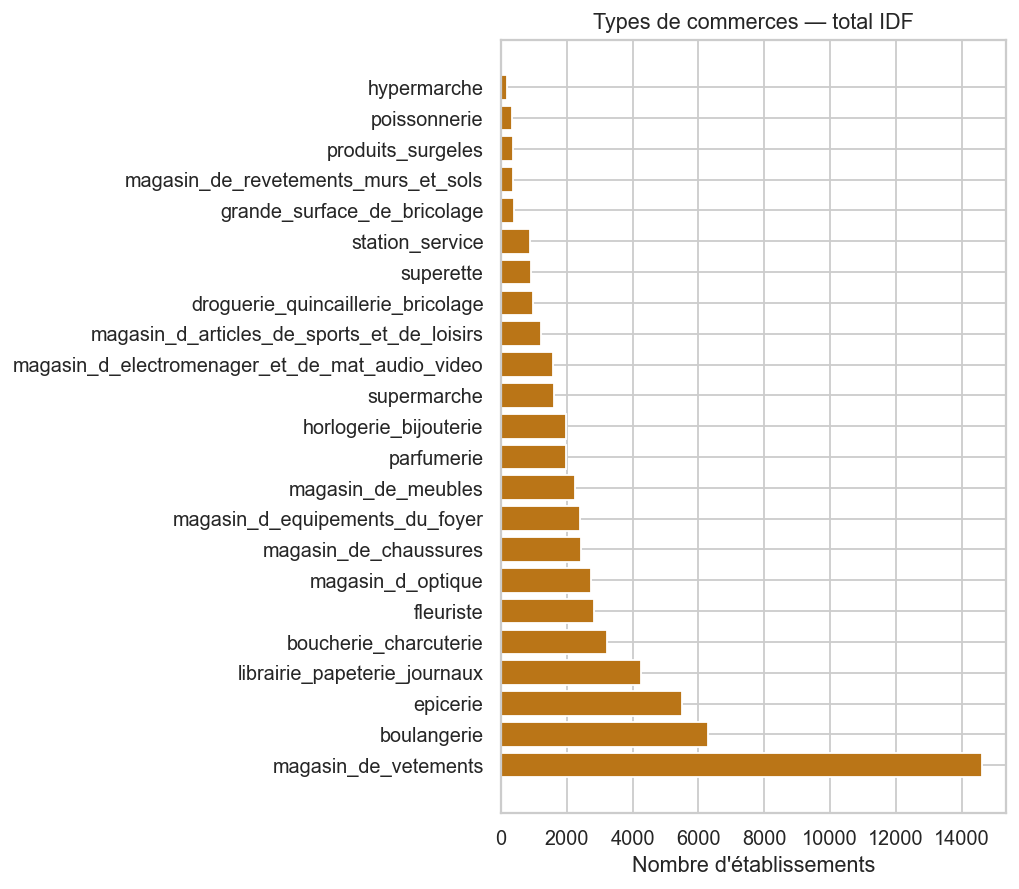

,Type,Total
0,magasin_de_vetements,14613
1,boulangerie,6299
2,epicerie,5491
3,librairie_papeterie_journaux,4248
4,boucherie_charcuterie,3233
5,fleuriste,2839
6,magasin_d_optique,2738
7,magasin_de_chaussures,2424
8,magasin_d_equipements_du_foyer,2410
9,magasin_de_meubles,2244


In [9]:
totaux = df[COMMERCE_COLS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(totaux.index[::-1], totaux.values[::-1], color='#BA7517')
ax.set_title("Types de commerces — total IDF")
ax.set_xlabel("Nombre d'établissements")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(totaux.reset_index().rename(columns={'index': 'Type', 0: 'Total'}).head(10))

## 8. Distribution géographique

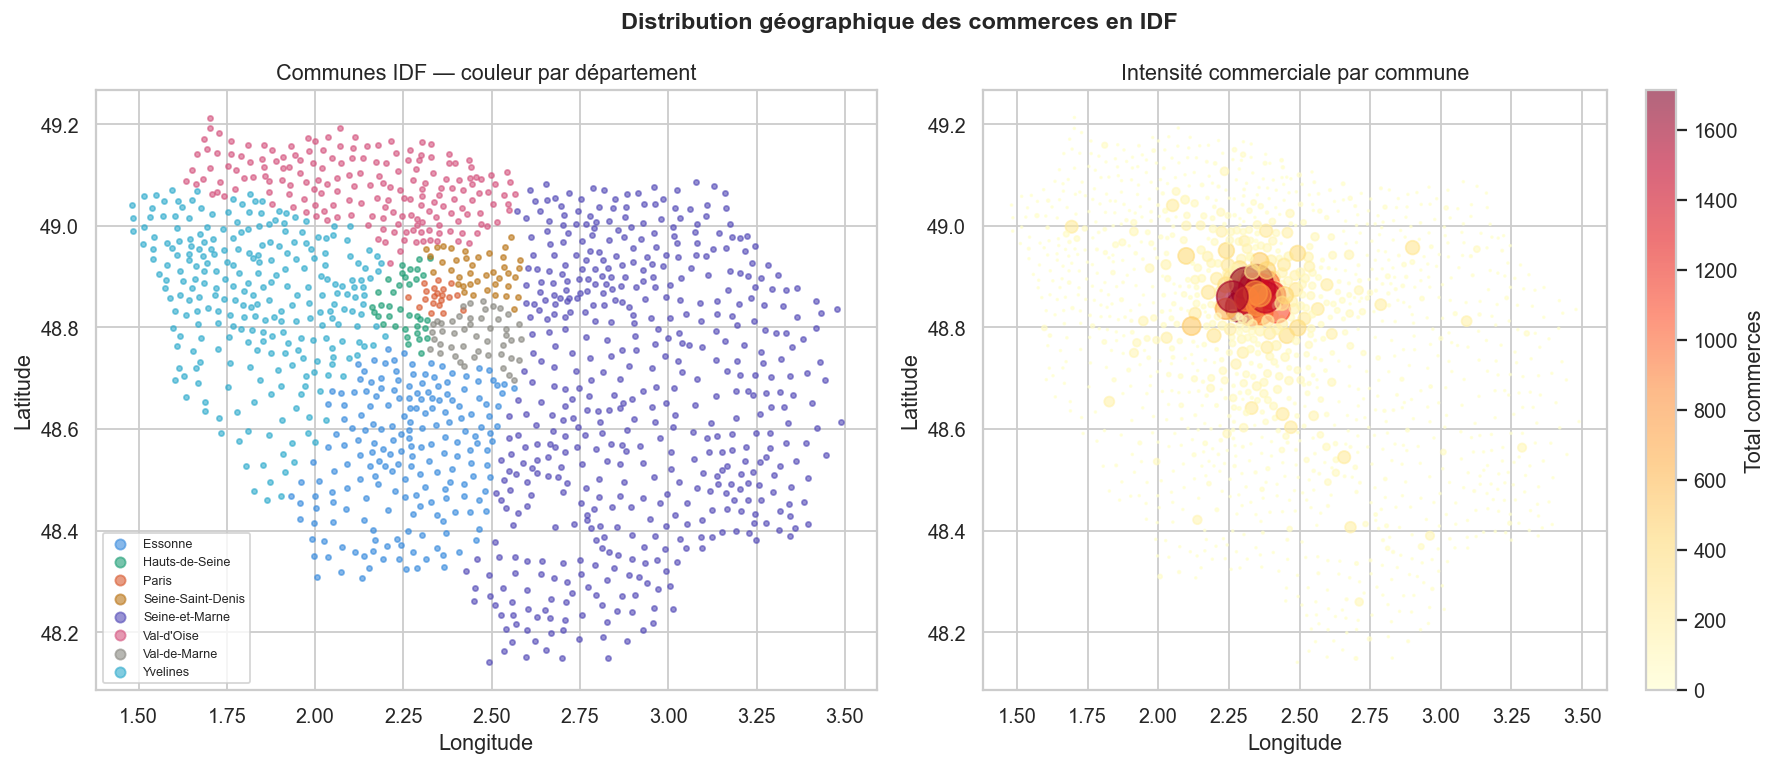

In [10]:
geo = df[['lat', 'lon', 'total_commerces', 'dept_label']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Vue colorée par département
for i, (dept, grp) in enumerate(geo.groupby('dept_label')):
    axes[0].scatter(grp['lon'], grp['lat'],
                    s=8, alpha=0.6, color=colors[i % len(colors)], label=dept)
axes[0].set_title("Communes IDF — couleur par département")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend(fontsize=7, markerscale=2)

# Intensité commerciale
sc = axes[1].scatter(geo['lon'], geo['lat'],
                     s=np.clip(geo['total_commerces'] / 5, 1, 300),
                     c=geo['total_commerces'], cmap='YlOrRd', alpha=0.6)
plt.colorbar(sc, ax=axes[1], label='Total commerces')
axes[1].set_title("Intensité commerciale par commune")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle('Distribution géographique des commerces en IDF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Cardinalité des colonnes catégorielles

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['geo_shape', 'geo_point_2d']]

cardinality = pd.DataFrame({
    'colonne'    : cat_cols,
    'unique'     : [df[c].nunique() for c in cat_cols],
    'exemple'    : [df[c].dropna().iloc[0] if not df[c].dropna().empty else 'N/A' for c in cat_cols],
    '% manquant' : [round(df[c].isnull().mean() * 100, 1) for c in cat_cols],
}).sort_values('unique', ascending=False)

display(cardinality)

,colonne,unique,exemple,% manquant
0,libelle_de_commune,1296,Valenton,0.0
1,dept_label,8,Val-de-Marne,0.0


## 10. Résumé final

In [12]:
print('=' * 55)
print('RÉSUMÉ EDA — commerces-par-commune.csv')
print('=' * 55)
print(f'  Lignes (communes)     : {len(df):,}')
print(f'  Colonnes              : {len(df.columns)}')
print(f'  Types de commerces    : {len(COMMERCE_COLS)}')
print(f'  Doublons              : {df.duplicated().sum()}')
print(f'  Cols avec NaN         : {(df.isnull().sum() > 0).sum()}')
print(f'  Départements          : {sorted(df["departement"].unique())}')
print(f'  Total commerces IDF   : {df["total_commerces"].sum():,.0f}')
print(f'  Commerce le + répandu : {df[COMMERCE_COLS].sum().idxmax()}')
print(f'  Communes sans commerce: {(df["total_commerces"]==0).sum()}')
print(f'  Lat range             : {df["lat"].min():.4f} → {df["lat"].max():.4f}')
print(f'  Lon range             : {df["lon"].min():.4f} → {df["lon"].max():.4f}')
print('=' * 55)

RÉSUMÉ EDA — commerces-par-commune.csv
  Lignes (communes)     : 1,300
  Colonnes              : 37
  Types de commerces    : 23
  Doublons              : 0
  Cols avec NaN         : 0
  Départements          : [np.int64(75), np.int64(77), np.int64(78), np.int64(91), np.int64(92), np.int64(93), np.int64(94), np.int64(95)]
  Total commerces IDF   : 59,419
  Commerce le + répandu : magasin_de_vetements
  Communes sans commerce: 355
  Lat range             : 48.1408 → 49.2132
  Lon range             : 1.4806 → 3.4892
